In [1]:
import random
import numpy as np

In [2]:
numbers = np.arange(1, 11)
random.shuffle(numbers)
numbers

array([10,  1,  3,  2,  7,  9,  6,  8,  4,  5])

In [3]:
even_numbers = np.where(numbers % 2 == 0, numbers, 0)
even_numbers

array([10,  0,  0,  2,  0,  0,  6,  8,  4,  0])

In [4]:
numbers = numbers.reshape(2, 5).ravel()
numbers = numbers * 3

numbers * 2

array([60,  6, 18, 12, 42, 54, 36, 48, 24, 30])

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
pd.Series(numbers, name="value")

0    30
1     3
2     9
3     6
4    21
5    27
6    18
7    24
8    12
9    15
Name: value, dtype: int64

In [8]:
pd.DataFrame(
    numbers.reshape(5, 2),
    columns=["first_column", "second_column"]
)

,first_column,second_column
0,30,3
1,9,6
2,21,27
3,18,24
4,12,15


In [9]:
titanic = pd.read_csv("train_titanic.csv", index_col="PassengerId")

In [10]:
titanic

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [11]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    str    
 10  Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [12]:
fare_95_percentile = titanic["Fare"].quantile(0.95)

In [13]:
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
titanic[titanic["Fare"] > 10]
titanic.iloc[::3]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S


In [15]:
titanic.iloc[:10, 3:6]

,Sex,Age,SibSp
PassengerId,,,
1,male,22.0,1
2,female,38.0,1
3,female,26.0,0
4,female,35.0,1
5,male,35.0,0
6,male,NaN,0
7,male,54.0,0
8,male,2.0,3
9,female,27.0,0


In [16]:
expensive_tickets = titanic["Fare"] > 30
titanic.loc[expensive_tickets, "Survived":"Sex"].head(10)

,Survived,Pclass,Name,Sex
PassengerId,,,,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female
7,0,1,"McCarthy, Mr. Timothy J",male
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female
14,0,3,"Andersson, Mr. Anders Johan",male
24,1,1,"Sloper, Mr. William Thompson",male
26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female
28,0,1,"Fortune, Mr. Charles Alexander",male
32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female


In [ ]:
def extract_title(full_name):
    name_before_dot = full_name.split(".")[0]
    return name_before_dot.split()[-1]


titanic["Title"] = titanic["Name"].apply(extract_title)

In [18]:
fare_stats_by_title = titanic.groupby("Title")["Fare"].agg(["mean", "median"])
fare_stats_by_title.loc["Mr", "mean"]

np.float64(24.44155996131528)

In [19]:
titanic["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [20]:
fare_stats_by_title = titanic.groupby("Title")["Fare"].agg(["mean", "median"])
title_counts = titanic["Title"].value_counts()

common_titles = ["Mr", "Miss", "Mrs", "Master"]
main_title_rows = titanic[titanic["Title"].isin(common_titles)]

main_title_rows

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,Mrs
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss


In [21]:
main_title_rows.groupby(["Title", "Pclass"])["Fare"].median().to_frame("median_fare")

median_fare
Title  Pclass             
Master 1         120.00000
       2          26.00000
       3          28.51250
Miss   1          91.75000
       2          13.00000
       3           8.75625
Mr     1          42.40000
       2          13.00000
       3           7.89580
Mrs    1          79.42500
       2          26.00000
       3          15.97500

In [23]:
def age_group(age):
    if pd.isna(age):
        return "unknown"
    if age < 12:
        return "child"
    if age < 18:
        return "teenager"
    if age < 25:
        return "young adult"
    return "adult"


titanic.drop(columns=["Cabin"])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Rev
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,Miss


In [24]:
titanic.rename(columns={"Cabin": "Cabin_info"})

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin_info,Embarked,Title
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Miss


In [25]:
left_table = pd.DataFrame(np.arange(16).reshape(4, 4))
right_table = pd.DataFrame(
    np.arange(32).reshape(8, 4),
    columns=["A", "B", "C", "D"]
)

In [26]:
left_table

,0,1,2,3
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15


In [27]:
left_table.columns = ["A", "B", "C", "D"]

In [28]:
left_table

,A,B,C,D
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15


In [29]:
right_table

,A,B,C,D
0,0,1,2,3
1,4,5,6,7
2,8,9,10,11
3,12,13,14,15
4,16,17,18,19
5,20,21,22,23
6,24,25,26,27
7,28,29,30,31


In [30]:
pd.concat([left_table, right_table], axis=1).reset_index(drop=True)

,A,B,C,D,A,B,C,D
0,0.0,1.0,2.0,3.0,0,1,2,3
1,4.0,5.0,6.0,7.0,4,5,6,7
2,8.0,9.0,10.0,11.0,8,9,10,11
3,12.0,13.0,14.0,15.0,12,13,14,15
4,NaN,NaN,NaN,NaN,16,17,18,19
5,NaN,NaN,NaN,NaN,20,21,22,23
6,NaN,NaN,NaN,NaN,24,25,26,27
7,NaN,NaN,NaN,NaN,28,29,30,31


Text(0.5, 0, 'Age')

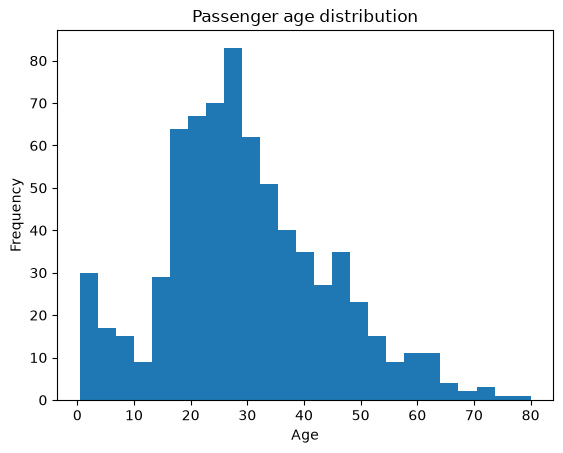

In [31]:
age_hist = titanic["Age"].plot(
    kind="hist",
    bins=25,
    title="Passenger age distribution"
)
age_hist.set_xlabel("Age")